# rtm-pymmcore Demo

Minimal example using Micro-Manager demo devices to run a real-time
feedback microscopy experiment.

## 1. Connect to a microscope

`MMDemo` loads the bundled Micro-Manager demo configuration.
Adjust `micromanager_path` if Micro-Manager is installed elsewhere.

In [1]:
from rtm_pymmcore.microscope.demo import MMDemo

mic = MMDemo(micromanager_path="C:\\Program Files\\Micro-Manager-2.0")

In [2]:
import rtm_pymmcore.core.utils as utils

utils.print_configs(mic.mmc)

Config Groups
├── Camera
│   ├── HighRes
│   ├── LowRes
│   └── MedRes
├── Channel
│   ├── Cy5
│   ├── DAPI
│   ├── FITC
│   └── Rhodamine
├── Channel-Multiband
│   ├── Cy5
│   ├── DAPI
│   ├── FITC
│   └── Rhodamine
├── LightPath
│   ├── Camera-left
│   ├── Camera-right
│   └── Eyepiece
├── Objective
│   ├── 10X
│   ├── 20X
│   └── 40X
└── System
    └── Startup

## 2. Set up the processing pipeline

In [3]:
import os
import tempfile

from rtm_pymmcore.core.data_structures import Channel, SegmentationMethod
from rtm_pymmcore.segmentation.base import OtsuSegmentator
from rtm_pymmcore.tracking.trackpy import TrackerTrackpy
from rtm_pymmcore.feature_extraction.simple import SimpleFE
from rtm_pymmcore.core.pipeline import ImageProcessingPipeline

path = os.path.join(tempfile.gettempdir(), "rtm-demo")

segmentators = [
    SegmentationMethod(
        name="labels",
        segmentation_class=OtsuSegmentator(),
        use_channel=0,
        save_tracked=True,
    )
]

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=segmentators,
    feature_extractor=SimpleFE("labels"),
    tracker=TrackerTrackpy(),
)

Directory C:\Users\Alex\AppData\Local\Temp\rtm-demo\tracks created 


## 3. Preview segmentation

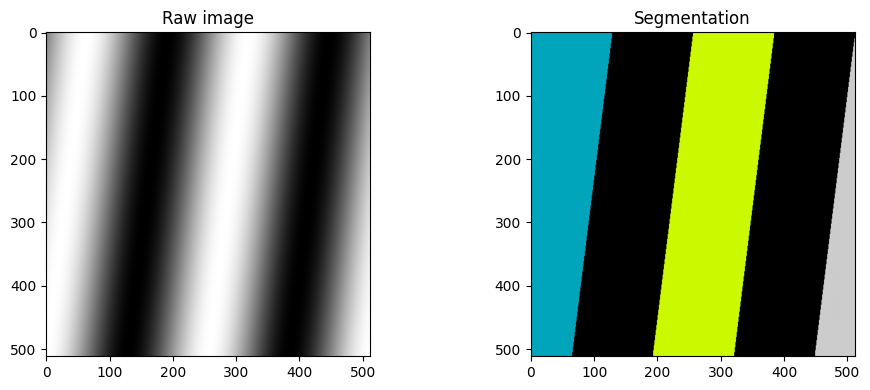

In [4]:
import matplotlib.pyplot as plt

mic.mmc.snapImage()
test_img = mic.mmc.getImage()

seg = OtsuSegmentator()
labels = seg.segment(test_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(test_img, cmap="gray")
axes[0].set_title("Raw image")
axes[1].imshow(labels, cmap="nipy_spectral")
axes[1].set_title("Segmentation")
plt.tight_layout()

## 4. Define the experiment with RTMSequence

In [5]:
from rtm_pymmcore.core.data_structures import RTMSequence, Channel

seq = RTMSequence(
    time_plan={"interval": 1.0, "loops": 10},
    stage_positions=[
        {"x": 0.0, "y": 0.0, "z": 0.0},
    ],
    channels=[
        {"config": "DAPI", "exposure": 50},
    ],
)

events = list(seq)
print(f"{len(events)} events")
events[0]

10 events


RTMEvent(index={'t': 0, 'p': 0}, min_start_time=0.0, x_pos=0.0, y_pos=0.0, z_pos=0.0, channels=(Channel(config='DAPI', exposure=50.0, group=None),))

## 5. Run the experiment

In [6]:
from rtm_pymmcore.core.controller import Controller
from rtm_pymmcore.core.writers import OmeZarrWriter

writer = OmeZarrWriter(storage_path=path)

ctrl = Controller(mic, pipeline, writer=writer)
ctrl.run_experiment(events)
ctrl.finish_experiment()

[04/02/26 16:26:05] INFO     MDA Started: GeneratorMDASequence()                                     ]8;id=494889;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py\_runner.py]8;;\:]8;id=524151;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py#378\378]8;;\

                    INFO     index={'t': 0, 'p': 0, 'c': 0} channel=Channel(config='DAPI')           ]8;id=396421;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py\_runner.py]8;;\:]8;id=557215;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py#337\337]8;;\
                             exposure=50.0 min_start_time=0.0 x_pos=0.0 y_pos=0.0 z_pos=0.0                        
                             metadata={'fov': 0, 'timestep': 0, 'fname': '000_00000', 'time': 0,                   
                             'stim': False, 'channels': ['DAPI'], 'img_type': <ImgType.IMG_RAW: 1>}                

[04/02/26 16:26:06] INFO     index={'t': 1, 'p': 0, 'c': 0} channel=Channel(config='DAPI')           ]8;id=812928;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py\_runner.py]8;;\:]8;id=648595;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py#337\337]8;;\
                             exposure=50.0 min_start_time=1.0 x_pos=0.0 y_pos=0.0 z_pos=0.0                        
                             metadata={'fov': 0, 'timestep': 1, 'fname': '000_00001', 'time': 1.0,                 
                             'stim': False, 'channels': ['DAPI'], 'img_type': <ImgType.IMG_RAW: 1>}                

[04/02/26 16:26:07] INFO     index={'t': 2, 'p': 0, 'c': 0} channel=Channel(config='DAPI')           ]8;id=268993;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py\_runner.py]8;;\:]8;id=147524;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py#337\337]8;;\
                             exposure=50.0 min_start_time=2.0 x_pos=0.0 y_pos=0.0 z_pos=0.0                        
                             metadata={'fov': 0, 'timestep': 2, 'fname': '000_00002', 'time': 2.0,                 
                             'stim': False, 'channels': ['DAPI'], 'img_type': <ImgType.IMG_RAW: 1>}                

[04/02/26 16:26:08] INFO     index={'t': 3, 'p': 0, 'c': 0} channel=Channel(config='DAPI')           ]8;id=47802;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py\_runner.py]8;;\:]8;id=69148;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py#337\337]8;;\
                             exposure=50.0 min_start_time=3.0 x_pos=0.0 y_pos=0.0 z_pos=0.0                        
                             metadata={'fov': 0, 'timestep': 3, 'fname': '000_00003', 'time': 3.0,                 
                             'stim': False, 'channels': ['DAPI'], 'img_type': <ImgType.IMG_RAW: 1>}                

...

[04/02/26 16:26:11] INFO     index={'t': 6, 'p': 0, 'c': 0} channel=Channel(config='DAPI')           ]8;id=376837;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py\_runner.py]8;;\:]8;id=919649;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py#337\337]8;;\
                             exposure=50.0 min_start_time=6.0 x_pos=0.0 y_pos=0.0 z_pos=0.0                        
                             metadata={'fov': 0, 'timestep': 6, 'fname': '000_00006', 'time': 6.0,                 
                             'stim': False, 'channels': ['DAPI'], 'img_type': <ImgType.IMG_RAW: 1>}                

[04/02/26 16:26:12] INFO     index={'t': 7, 'p': 0, 'c': 0} channel=Channel(config='DAPI')           ]8;id=417937;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py\_runner.py]8;;\:]8;id=493013;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py#337\337]8;;\
                             exposure=50.0 min_start_time=7.0 x_pos=0.0 y_pos=0.0 z_pos=0.0                        
                             metadata={'fov': 0, 'timestep': 7, 'fname': '000_00007', 'time': 7.0,                 
                             'stim': False, 'channels': ['DAPI'], 'img_type': <ImgType.IMG_RAW: 1>}                

[04/02/26 16:26:13] INFO     index={'t': 8, 'p': 0, 'c': 0} channel=Channel(config='DAPI')           ]8;id=168168;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py\_runner.py]8;;\:]8;id=385801;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py#337\337]8;;\
                             exposure=50.0 min_start_time=8.0 x_pos=0.0 y_pos=0.0 z_pos=0.0                        
                             metadata={'fov': 0, 'timestep': 8, 'fname': '000_00008', 'time': 8.0,                 
                             'stim': False, 'channels': ['DAPI'], 'img_type': <ImgType.IMG_RAW: 1>}                

[04/02/26 16:26:14] INFO     index={'t': 9, 'p': 0, 'c': 0} channel=Channel(config='DAPI')           ]8;id=158593;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py\_runner.py]8;;\:]8;id=582889;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py#337\337]8;;\
                             exposure=50.0 min_start_time=9.0 x_pos=0.0 y_pos=0.0 z_pos=0.0                        
                             metadata={'fov': 0, 'timestep': 9, 'fname': '000_00009', 'time': 9.0,                 
                             'stim': False, 'channels': ['DAPI'], 'img_type': <ImgType.IMG_RAW: 1>}                

                    INFO     MDA Finished: GeneratorMDASequence()                                    ]8;id=569362;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py\_runner.py]8;;\:]8;id=370691;file://c:\Users\Alex\Programmierung\01_git\PhD\rtm-pymmcore_main\.venv\Lib\site-packages\pymmcore_plus\mda\_runner.py#465\465]8;;\

## 6. Inspect results

In [7]:
import pandas as pd

# Tracking data
tracks = pd.read_parquet(os.path.join(path, "tracks", "0_latest.parquet"))
print(
    f"Tracked {tracks['particle'].nunique()} cells across {tracks['timestep'].nunique()} frames"
)
tracks.head()

Tracked 6 cells across 10 frames


,label,x,y,fov,timestep,fname,time,stim,channels,time_acquired,img_shape,particle,fov_timestep,area
0,1,213.326255,34.511583,0,0,000_00000,0.0,False,[DAPI],2026-04-02-16:26:05,"[512, 512]",0,0,33152.0
1,2,255.493678,256.064266,0,0,000_00000,0.0,False,[DAPI],2026-04-02-16:26:05,"[512, 512]",1,0,65727.0
2,3,298.408012,477.006784,0,0,000_00000,0.0,False,[DAPI],2026-04-02-16:26:05,"[512, 512]",2,0,32575.0
3,1,172.078254,21.090242,0,1,000_00001,1.0,False,[DAPI],2026-04-02-16:26:06,"[512, 512]",0,1,16766.0
4,2,255.493678,224.064266,0,1,000_00001,1.0,False,[DAPI],2026-04-02-16:26:06,"[512, 512]",1,1,65727.0


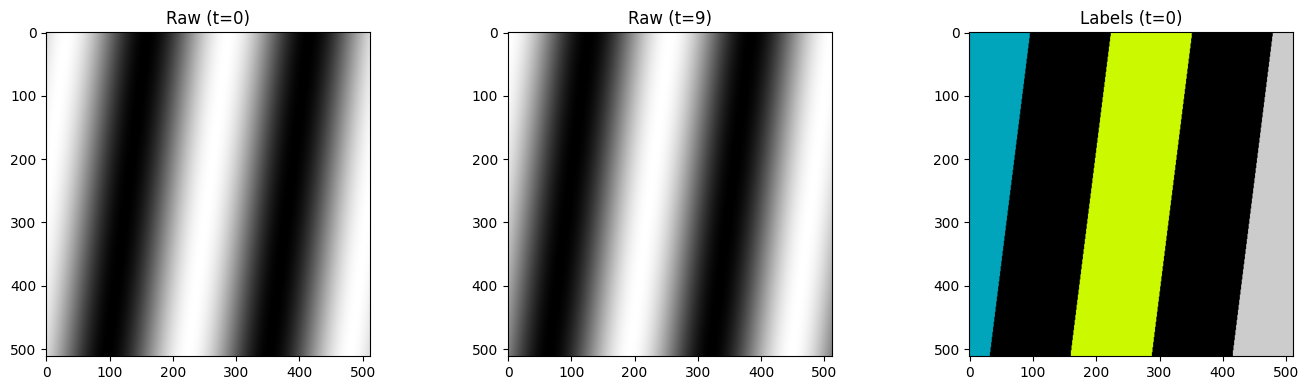

In [8]:
import zarr

# Open the OME-Zarr store
store = zarr.open(os.path.join(path, "acquisition.ome.zarr"), mode="r")
raw = store["0"]
lbl = store["labels/labels/0"]

# Show first and last raw frame + labels
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(raw[0], cmap="gray")
axes[0].set_title("Raw (t=0)")
axes[1].imshow(raw[9], cmap="gray")
axes[1].set_title("Raw (t=9)")
axes[2].imshow(lbl[0], cmap="nipy_spectral")
axes[2].set_title("Labels (t=0)")
plt.tight_layout()